In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, roc_curve, auc, accuracy_score, roc_auc_score
from sklearn.inspection import permutation_importance

In [2]:
col_names = ['date', 'precipitation',	'temp_max',	'temp_min',	'wind', 'weather'] 

df = pd.read_csv('../../seattle-weather(in).csv', names=col_names, header=None, skiprows=1)
df = df.drop('date', axis=1)

In [3]:
X = df.drop('weather', axis = 1)
y = df['weather']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 42)

In [4]:
# 2. Manual scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [13]:
# 3. Model + Gridsearch
knn = KNeighborsClassifier()
param_grid = {
    "n_neighbors": [3, 5, 7, 9, 11, 13, 15], 
    "weights": ["uniform", "distance"], 
    "p": [1, 2],
    "algorithm": ["auto", "ball_tree", "kd_tree", "brute"]
}

grid_search = GridSearchCV(estimator=knn, param_grid=param_grid, cv=5, scoring="accuracy", n_jobs=-1, verbose=1)
grid_search.fit(X_train_scaled, y_train)
best_model = grid_search.best_estimator_
print("Best Hyperparameter:", grid_search.best_params_)

Fitting 5 folds for each of 112 candidates, totalling 560 fits
Best Hyperparameter: {'algorithm': 'auto', 'n_neighbors': 11, 'p': 1, 'weights': 'distance'}


C:\Users\gbgar\documents\TEC\FJ2026\TC2004B-gil-brandon\TC2004B_env\Lib\site-packages\sklearn\model_selection\_search.py:1137: UserWarning: One or more of the test scores are non-finite: [0.69963176 0.71919656 0.69865615 0.71724055 0.73585366 0.73779053
 0.72409374 0.73289813 0.75148733 0.74953611 0.72406504 0.73191296
 0.74756576 0.7505165  0.73679101 0.73875179 0.7514682  0.75931133
 0.7367671  0.74364419 0.74658058 0.7554089  0.73285509 0.7397274
 0.7504878  0.75637494 0.73285509 0.73877092 0.70061215 0.72017695
 0.69963654 0.71822095 0.73585366 0.73779053 0.72409374 0.73289813
 0.75148733 0.74953611 0.72406504 0.73191296 0.74756576 0.7505165
 0.73679101 0.73875179 0.7514682  0.75931133 0.7367671  0.74364419
 0.74658058 0.7554089  0.73285509 0.7397274  0.7504878  0.75637494
 0.73285509 0.73877092 0.69963176 0.71919656 0.69865615 0.71724055
 0.73585366 0.73779053 0.72409374 0.73289813 0.75148733 0.74953611
 0.72406504 0.73191296 0.74756576 0.7505165  0.73679101 0.73875179
 0.7514682 


Classification Report (Test):
              precision    recall  f1-score   support

     drizzle       0.33      0.07      0.12        14
         fog       0.14      0.03      0.05        32
        rain       0.88      0.84      0.86       192
        snow       1.00      0.12      0.22         8
         sun       0.69      0.88      0.77       193

    accuracy                           0.76       439
   macro avg       0.61      0.39      0.40       439
weighted avg       0.73      0.76      0.73       439



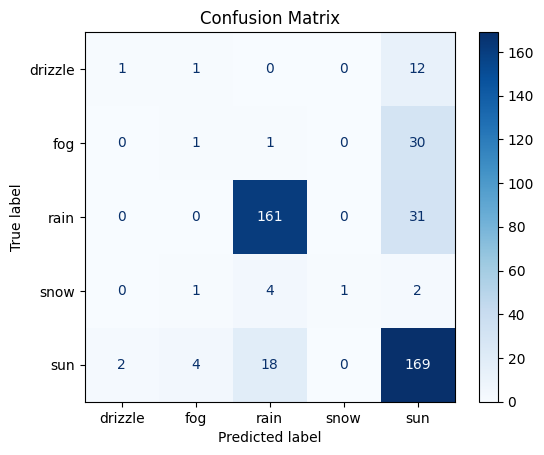

In [16]:
# 4. Evakuation
y_pred = best_model.predict(X_test_scaled)

print('\nClassification Report (Test):')
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred, labels=best_model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_model.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()